<a href="https://colab.research.google.com/github/anasayago/challenge3-data-science-latam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Parte 2: Predicción de Cancelación (Churn)

1. Preparación de Datos
  * Identificar el conjunto de datos
  * Limpieza de datos
  * Manejo de valores nulos
  * Detección y tratamiento de outliers
2. Codificación de variables categóricas
  * One-hot encoding
  * Label encoding
3. Normalización/Escalamiento
  * StandardScaler
  * MinMaxScaler
4. Análisis de Correlación y Selección de Variables
  * Matriz de correlación
  * Técnicas de selección:
    * Correlación de Pearson
    * Análisis de importancia de características
    * Reducción de dimensionalidad (PCA)
5. Entrenamiento de Modelos de Clasificación:
  * Regresión Logística
  * Árbol de Decisión
  * Random Forest
  * Gradient Boosting
  * Support Vector Machine
6. Evaluación de Rendimiento Métricas
  * Accuracy
  * Precision
  * Recall
  * F1-Score
  * Curva ROC
  * Matriz de Confusión
7. Interpretación de Resultados
  * Importancia de variables
  * Análisis de features más relevantes
  * Distribución de probabilidades de cancelación
8. Conclusión Estratégica
  * Factores clave de cancelación
  * Recomendaciones de negocio
  * Visualización de insights principales

## 1. Preparación de Datos

In [134]:
#importar el archivo de datos
import pandas as pd
#cargar el archivo de datos
data = pd.read_csv('datos_tratados.csv',sep=',')
data.shape



(7043, 24)

In [135]:
#mostrar las primeras filas del archivo de datos
data.head()

,ID Cliente,Abandono,Género,Mayor de 65 años,Tiene Pareja,Tiene Dependientes,Duración del Contrato (meses),Servicio Telefónico,Múltiples Líneas,Servicio de Internet,...,TV por Cable,Streaming de Películas,Tipo de Contrato,Facturación Sin Papel,Método de Pago,Costo Mensual,Costo Total,Costo Diario,Rango de Contrato,Cantidad de Servicios Contratados
0,0002-ORFBO,0,F,False,1,1,9,1,0,DSL,...,1,0,Anual,1,Cheque por Correo,65.6,593.30,2.19,6-10,4
1,0003-MKNFE,0,M,False,0,0,9,1,1,DSL,...,0,1,Mensual,0,Cheque por Correo,59.9,542.40,2.00,6-10,3
2,0004-TLHLJ,1,M,False,0,0,4,1,0,Fibra Óptica,...,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.46,0-5,2
3,0011-IGKFF,1,M,True,1,0,13,1,0,Fibra Óptica,...,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.27,11-15,5
4,0013-EXCHZ,1,F,True,1,0,3,1,0,Fibra Óptica,...,1,0,Mensual,1,Cheque por Correo,83.9,267.40,2.80,0-5,3


### **Limpieza**

In [136]:
#eliminar las columnas que no son necesarias
data = data.drop(columns=['ID Cliente','Costo Diario','Rango de Contrato'])

Las columnas relacionadas con los servicios se contabilizaron en Cantidad de Servicios Contratados. Por lo tanto se considera eliminar esas variables para reducir la dimensionalidad del dataset y simplificar la estructura de datos y se mantiene la información crítica

In [137]:
def analizar_redundancia(df, columnas):
    print("Análisis de Redundancia:")
    for columna in columnas:
        # Conteo único de valores
        valores_unicos = df[columna].nunique()
        # Porcentaje de valores binarios
        porcentaje_binario = (df[columna].value_counts(normalize=True).iloc[0] * 100)

        print(f"\n{columna}:")
        print(f"  Valores únicos: {valores_unicos}")
        print(f"  Porcentaje del valor más común: {porcentaje_binario:.2f}%")

# Columnas de servicios individuales
columnas_servicios = [
    'Servicio Telefónico',
    'Múltiples Líneas',
    'Protección del Dispositivo',
    'Seguridad en Línea',
    'Respaldo en Línea',
    'Soporte Técnico',
    'TV por Cable',
    'Streaming de Películas'
]

analizar_redundancia(data, columnas_servicios)

Análisis de Redundancia:

Servicio Telefónico:
  Valores únicos: 2
  Porcentaje del valor más común: 90.32%

Múltiples Líneas:
  Valores únicos: 2
  Porcentaje del valor más común: 57.82%

Protección del Dispositivo:
  Valores únicos: 2
  Porcentaje del valor más común: 65.61%

Seguridad en Línea:
  Valores únicos: 2
  Porcentaje del valor más común: 71.33%

Respaldo en Línea:
  Valores únicos: 2
  Porcentaje del valor más común: 65.51%

Soporte Técnico:
  Valores únicos: 2
  Porcentaje del valor más común: 70.98%

TV por Cable:
  Valores únicos: 2
  Porcentaje del valor más común: 61.56%

Streaming de Películas:
  Valores únicos: 2
  Porcentaje del valor más común: 61.21%


In [138]:
#eliminar columnas relacionadas con Servicios Contratados
columnas_servicios= ['Servicio Telefónico', 'Múltiples Líneas','Protección del Dispositivo','Seguridad en Línea', 'Respaldo en Línea', 'Soporte Técnico','TV por Cable','Streaming de Películas']
data = data.drop(columns=columnas_servicios)

In [139]:
#conocer los metadatos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Abandono                           7043 non-null   int64  
 1   Género                             7043 non-null   object 
 2   Mayor de 65 años                   7043 non-null   bool   
 3   Tiene Pareja                       7043 non-null   int64  
 4   Tiene Dependientes                 7043 non-null   int64  
 5   Duración del Contrato (meses)      7043 non-null   int64  
 6   Servicio de Internet               7043 non-null   object 
 7   Tipo de Contrato                   7043 non-null   object 
 8   Facturación Sin Papel              7043 non-null   int64  
 9   Método de Pago                     7043 non-null   object 
 10  Costo Mensual                      7043 non-null   float64
 11  Costo Total                        7043 non-null   float

No se detectan valores nulos

### Analisis Exploratorio

In [140]:
data.describe()

,Abandono,Tiene Pareja,Tiene Dependientes,Duración del Contrato (meses),Facturación Sin Papel,Costo Mensual,Costo Total,Cantidad de Servicios Contratados
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.483033,0.299588,32.371149,0.592219,64.761692,2279.734304,3.362914
std,0.441561,0.499748,0.458110,24.559481,0.491457,30.090047,2266.794470,2.062031
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,0.000000,35.500000,398.550000,1.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,70.350000,1394.550000,3.000000
75%,1.000000,1.000000,1.000000,55.000000,1.000000,89.850000,3786.600000,5.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000,8684.800000,8.000000


In [141]:
data.describe(include='object')

,Género,Servicio de Internet,Tipo de Contrato,Método de Pago
count,7043,7043,7043,7043
unique,2,3,3,4
top,M,Fibra Óptica,Mensual,Cheque electrónico
freq,3555,3096,3875,2365


### Gráficas de Variables númericas

<Figure size 1500x1000 with 0 Axes>

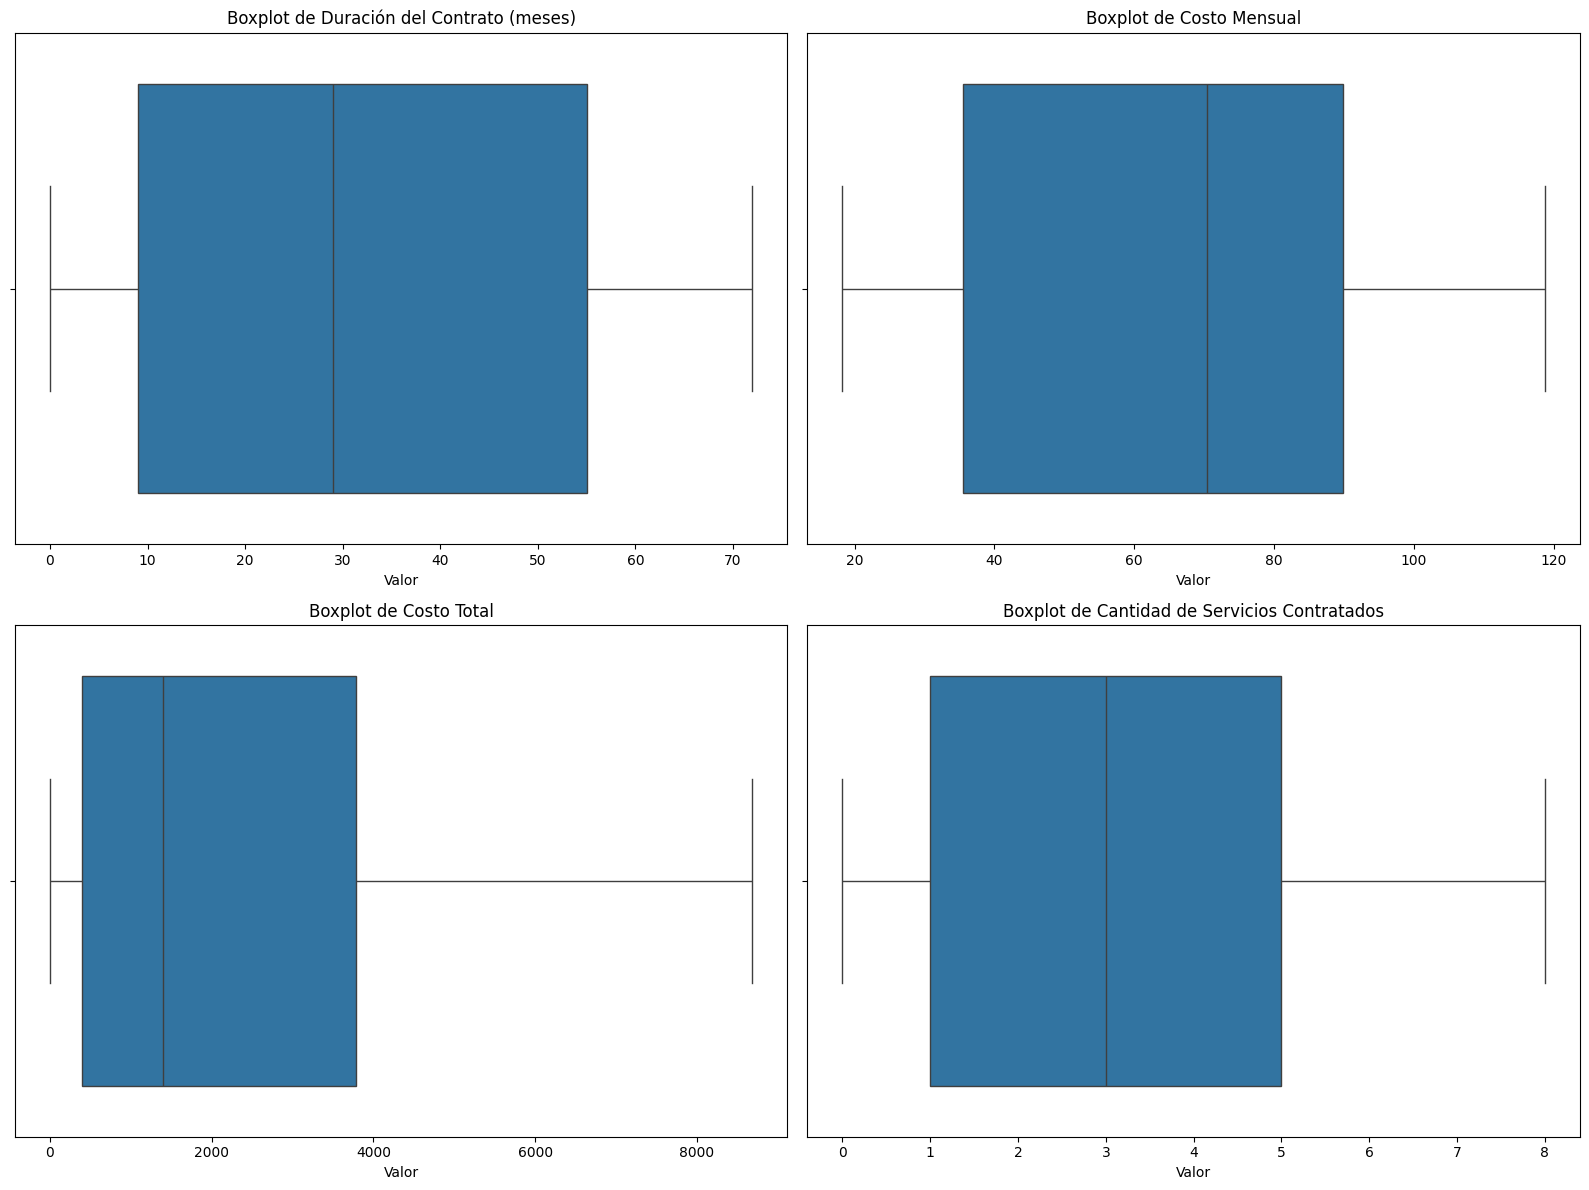

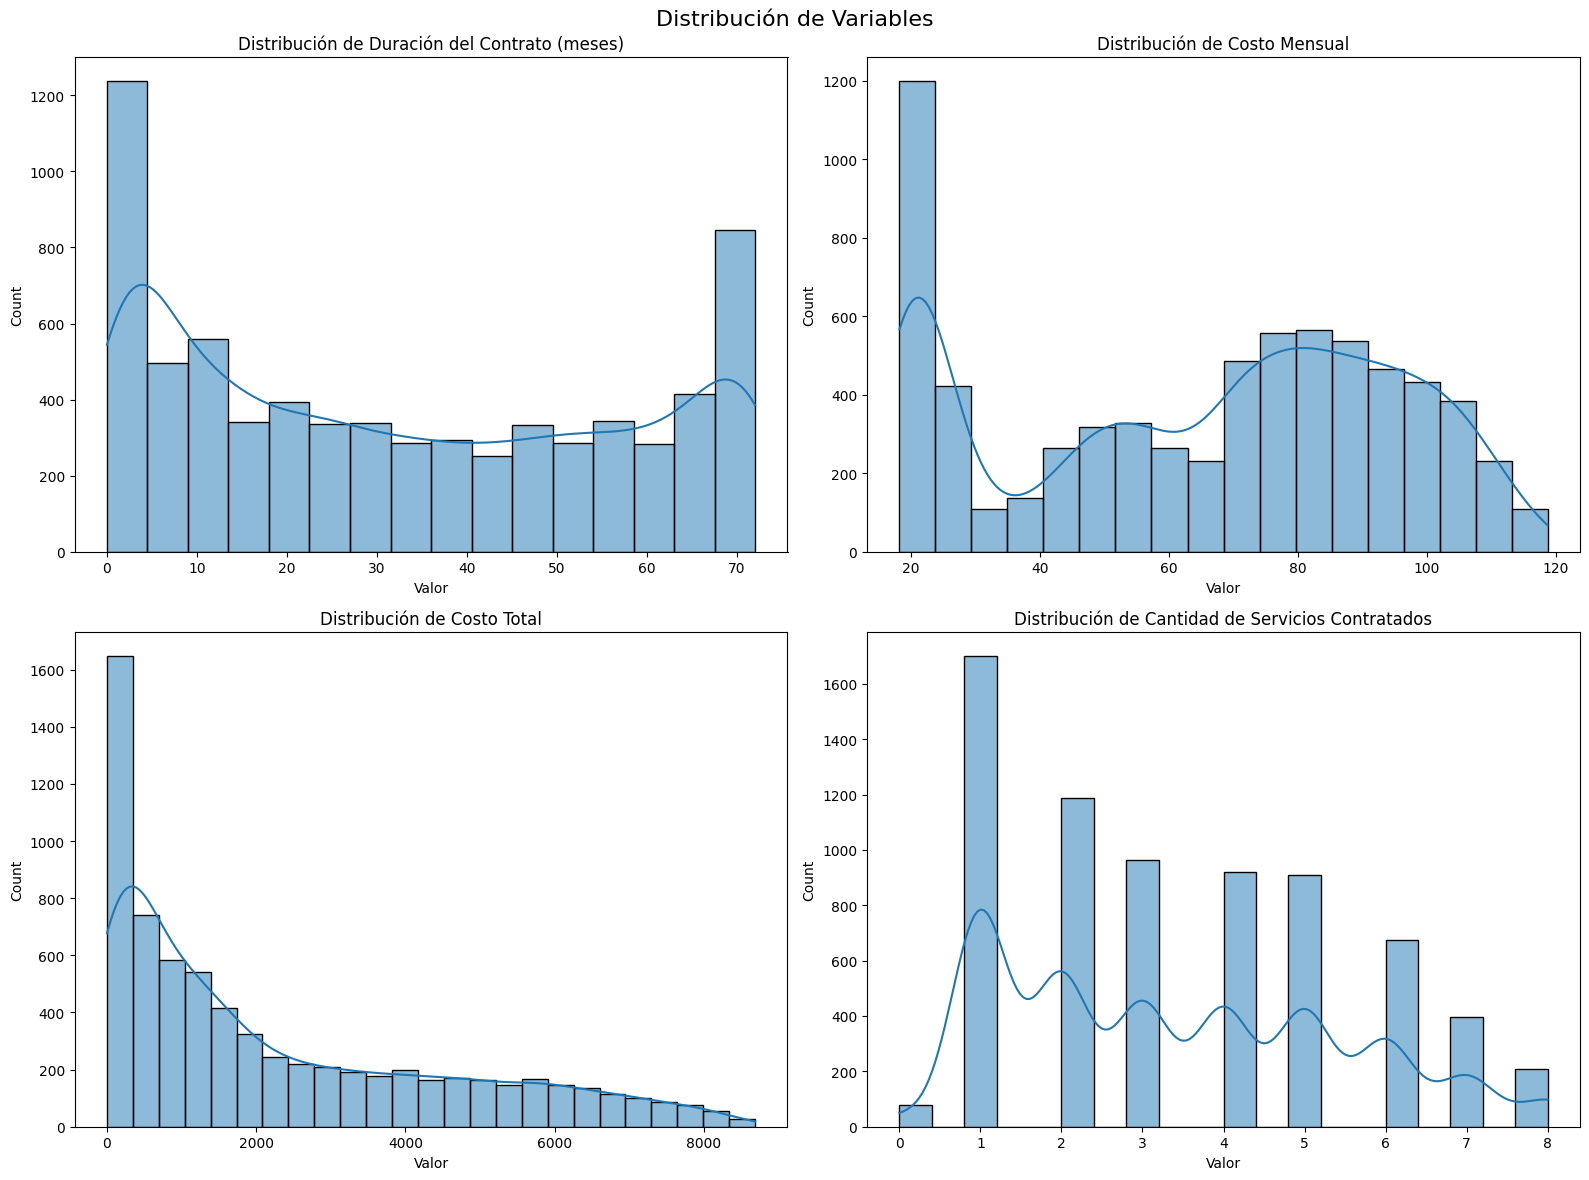

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

# Columnas numéricas
columnas_numericas = [
    'Duración del Contrato (meses)',
    'Costo Mensual',
    'Costo Total',
    'Cantidad de Servicios Contratados'
]

# Crear subplots
fig, axs = plt.subplots(2, 2, figsize=(16,12))

# Boxplots
for i, columna in enumerate(columnas_numericas):
    # Calcular fila y columna del subplot
    row = i // 2
    col = i % 2

    # Boxplot
    sns.boxplot(x=data[columna], ax=axs[row, col])
    axs[row, col].set_title(f'Boxplot de {columna}')
    axs[row, col].set_xlabel('Valor')

# Ajustar espaciado
plt.tight_layout()
plt.show()

# Gráficos adicionales: Histogramas con distribución
fig, axs = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle('Distribución de Variables', fontsize=16)

for i, columna in enumerate(columnas_numericas):
    # Calcular fila y columna del subplot
    row = i // 2
    col = i % 2

    # Histograma con distribución
    sns.histplot(data[columna], kde=True, ax=axs[row, col])
    axs[row, col].set_title(f'Distribución de {columna}')
    axs[row, col].set_xlabel('Valor')

plt.tight_layout()
plt.show()


Análisis gráfico respecto a la variable respuesta

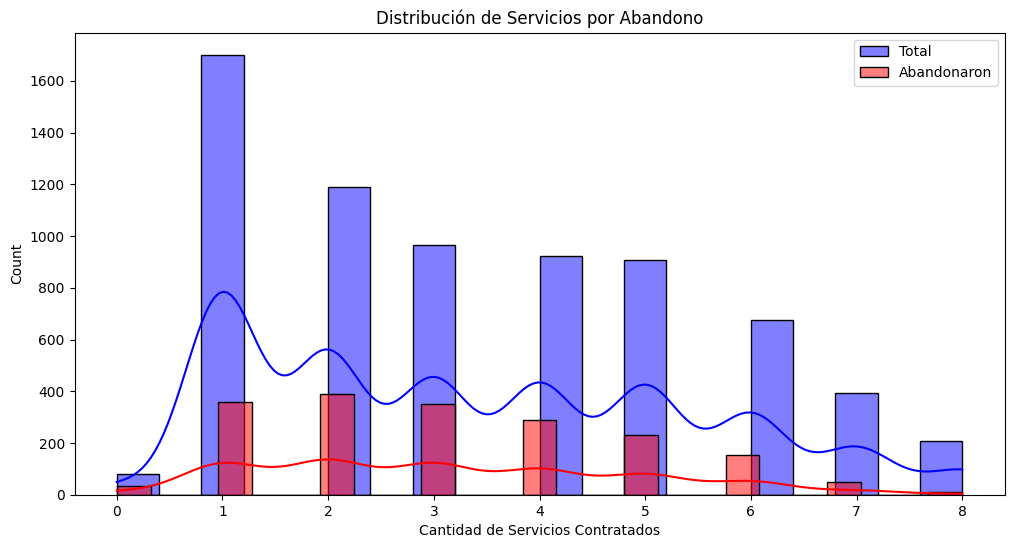

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
# Distribución general
sns.histplot(data=data, x='Cantidad de Servicios Contratados',
             kde=True, color='blue', alpha=0.5, label='Total')

# Distribución por abandono
sns.histplot(data=data[data['Abandono']==1],
             x='Cantidad de Servicios Contratados',
             kde=True, color='red', alpha=0.5, label='Abandonaron')

plt.title('Distribución de Servicios por Abandono')
plt.legend()
plt.show()

### Gráficos de variables categóricas

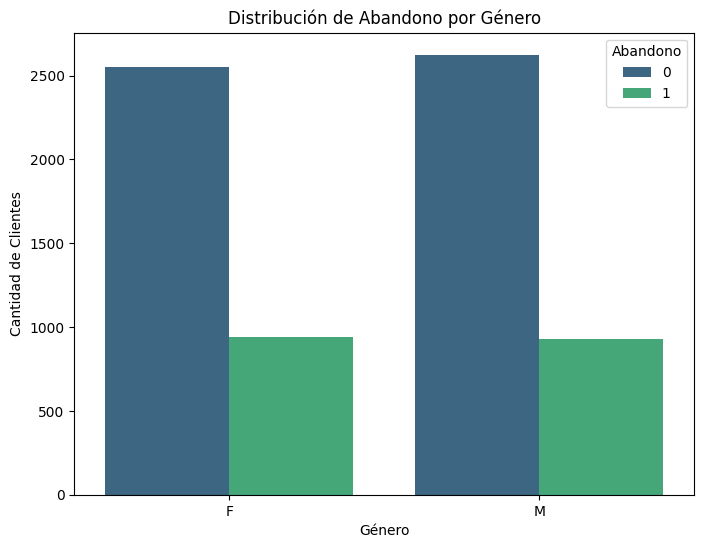

In [107]:
import matplotlib.pyplot as plt
# Gráfica de barra apilada para Abandono y Género
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Género', hue='Abandono', palette='viridis')
plt.title('Distribución de Abandono por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [108]:
# Prueba de Chi-cuadrado para considerar eliminar la variable ya que no parece tener impacto en el abandono
from scipy.stats import chi2_contingency

contingencia = pd.crosstab(data['Género'], data['Abandono'])
chi2, p_valor, dof, esperado = chi2_contingency(contingencia)

print(f"P-valor: {p_valor}")

P-valor: 0.48657873605618596


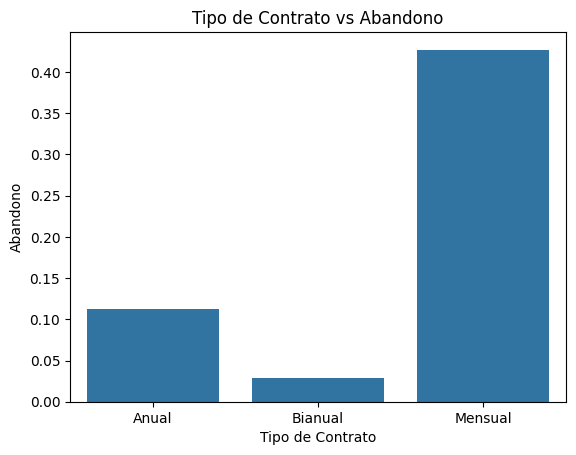

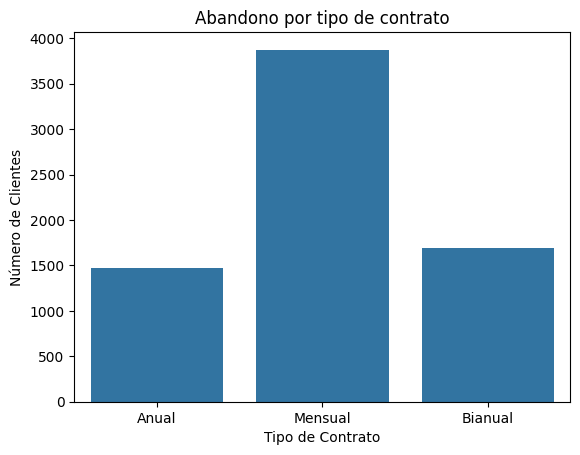

In [109]:
avg_delay = data.groupby('Tipo de Contrato')['Abandono'].mean().reset_index()
sns.barplot(x='Tipo de Contrato',y='Abandono',data=avg_delay)
plt.title('Tipo de Contrato vs Abandono')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Abandono')
plt.show()

sns.countplot(data=data,x='Tipo de Contrato')
plt.title('Abandono por tipo de contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

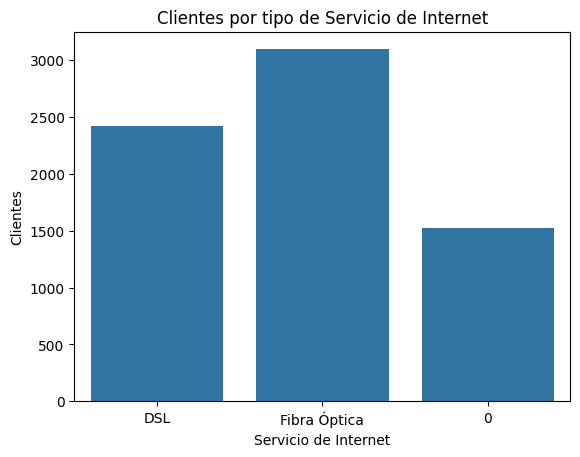

In [111]:
cantidad = data['Servicio de Internet'].value_counts()
sns.countplot(data=data,x='Servicio de Internet')
plt.title('Clientes por tipo de Servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Clientes')
plt.show()

### Distribución de los Datos

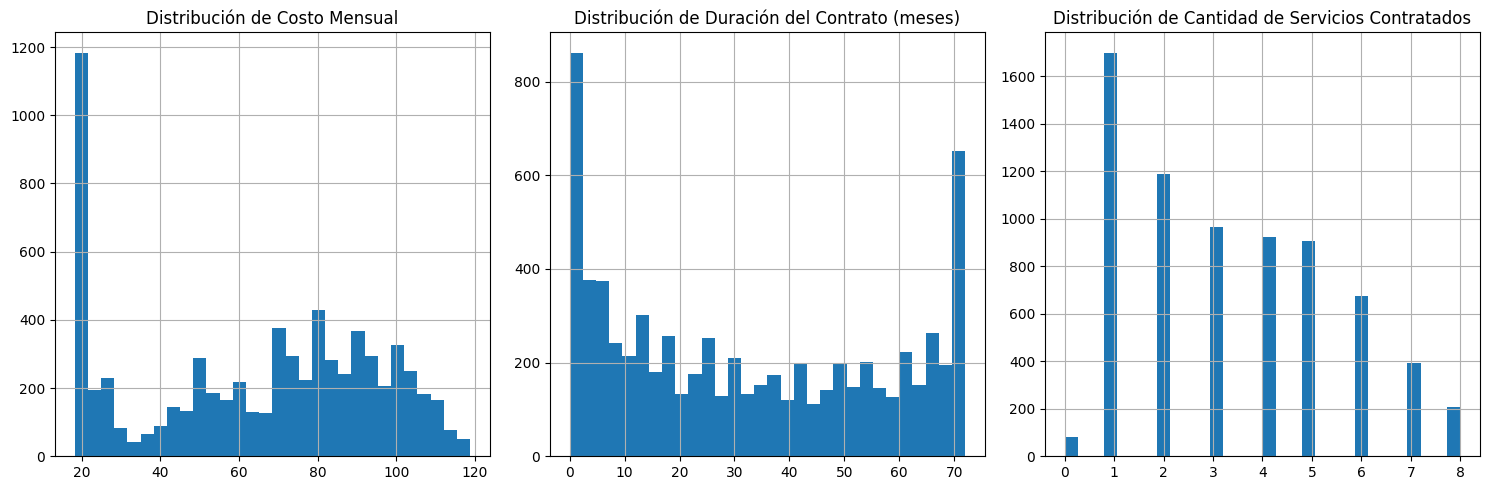

In [112]:
plt.figure(figsize=(15,5))
variables = ['Costo Mensual', 'Duración del Contrato (meses)', 'Cantidad de Servicios Contratados']
for i, var in enumerate(variables, 1):
    plt.subplot(1,3,i)
    data[var].hist(bins=30)
    plt.title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

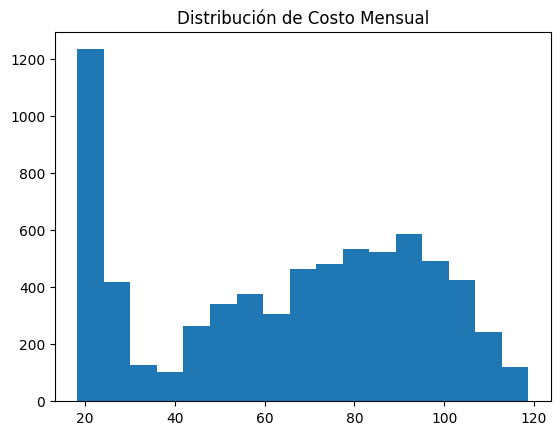

In [114]:
import numpy as np
import matplotlib.pyplot as plt

def freedman_diaconis_bin_width(data):
    IQR = np.percentile(data, 75) - np.percentile(data, 25)
    n = len(data)
    bin_width = 2 * IQR / (n ** (1/3))
    return bin_width

# Calcular ancho óptimo de bins
bin_width = freedman_diaconis_bin_width(data['Costo Mensual'])
num_bins = int((data['Costo Mensual'].max() - data['Costo Mensual'].min()) / bin_width)

plt.hist(data['Costo Mensual'], bins=num_bins)
plt.title('Distribución de Costo Mensual')
plt.show()

### Codificación

In [162]:
def categorizar_servicios_abandono(df):
    # Calcular tasa de abandono por número de servicios
    abandono_por_servicios = df.groupby('Cantidad de Servicios Contratados')['Abandono'].mean()

    def categorizar(num_servicios):
        if num_servicios <= 2:
            return 'Pocos'
        elif num_servicios <= 4:
            return 'Medio'
        else:
            return 'Muchos'

    return categorizar

# Aplicar la categorización
def aplicar_categoria_abandono(df):
    # Crear la función de categorización
    categorizar = categorizar_servicios_abandono(df)

    # Crear nueva columna
    data['Categoria_Servicios'] = data['Cantidad de Servicios Contratados'].apply(categorizar)

    return df

# Ejemplo de uso
data = aplicar_categoria_abandono(data)

/tmp/ipython-input-163-1404472000.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Categoria_Servicios')['Abandono'].mean().plot(kind='bar')


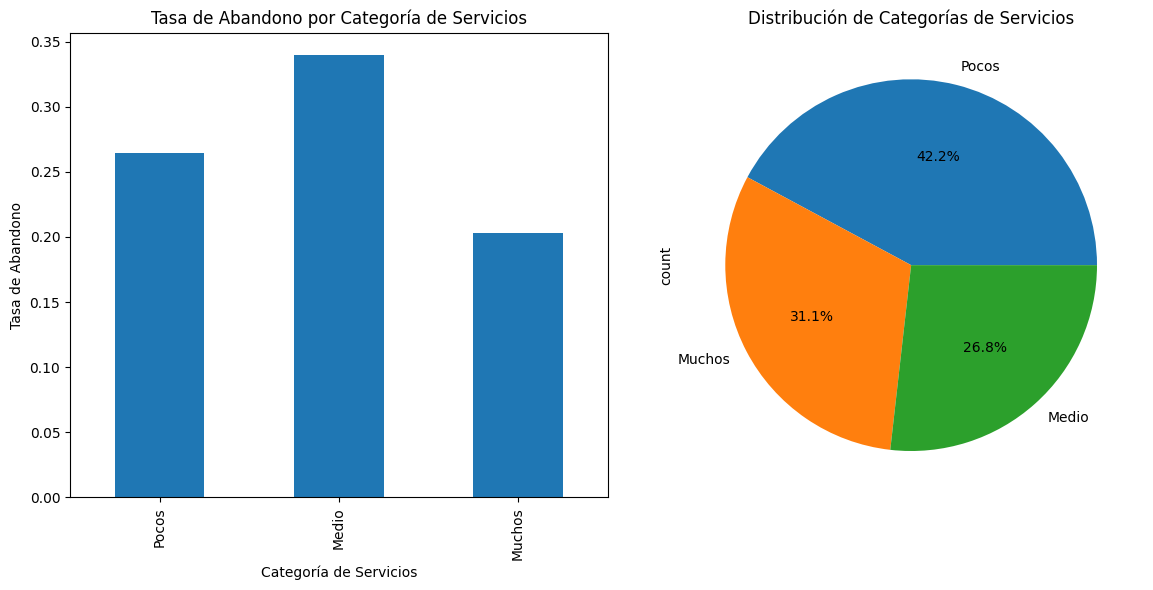

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
#ordenar categorias por pocos, medios, muchos para el grafico
data['Categoria_Servicios'] = pd.Categorical(data['Categoria_Servicios'], categories=['Pocos', 'Medio', 'Muchos'])

# Gráfico de barras de tasa de abandono
plt.subplot(1, 2, 1)
data.groupby('Categoria_Servicios')['Abandono'].mean().plot(kind='bar')
plt.title('Tasa de Abandono por Categoría de Servicios')
plt.xlabel('Categoría de Servicios')
plt.ylabel('Tasa de Abandono')


# Gráfico de distribución de categorías
plt.subplot(1, 2, 2)
data['Categoria_Servicios'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Categorías de Servicios')

plt.tight_layout()
plt.show()

In [115]:
# Codificar variables categóricas usando one-hot encoding
data_encoded = pd.get_dummies(data, drop_first=True)
# Mostrar las primeras filas del nuevo DataFrame codificado
data_encoded.head()

,Abandono,Mayor de 65 años,Tiene Pareja,Tiene Dependientes,Duración del Contrato (meses),Facturación Sin Papel,Costo Mensual,Costo Total,Cantidad de Servicios Contratados,Género_M,Servicio de Internet_DSL,Servicio de Internet_Fibra Óptica,Tipo de Contrato_Bianual,Tipo de Contrato_Mensual,Método de Pago_Cheque por Correo,Método de Pago_Tarjeta de crédito (automático),Método de Pago_Transferencia bancaria (automático)
0,0,False,1,1,9,1,65.6,593.30,4,False,True,False,False,False,True,False,False
1,0,False,0,0,9,0,59.9,542.40,3,True,True,False,False,True,True,False,False
2,1,False,0,0,4,1,73.9,280.85,2,True,False,True,False,True,False,False,False
3,1,True,1,0,13,1,98.0,1237.85,5,True,False,True,False,True,False,False,False
4,1,True,1,0,3,1,83.9,267.40,3,False,False,True,False,True,True,False,False


In [116]:
# Proporción de clientes que abandonaron vs los que aun estan activos
proporcion = data['Abandono'].value_counts(normalize=True)
print("Proporción de cada clase:")
print(proporcion)
# Valores absolutos
print("\nCantidad de clientes por clase:")
print(data['Abandono'].value_counts())

Proporción de cada clase:
Abandono
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Cantidad de clientes por clase:
Abandono
0    5174
1    1869
Name: count, dtype: int64


In [117]:
# Variable dependiente
y = data_encoded['Abandono']
# Variables independientes
X = data_encoded.drop(columns=['Abandono'])

In [119]:
# aplicar SMOTE para balancear el dataset
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Mostrar la proporción de clases después de aplicar SMOTE
print("\nProporción de clases después de SMOTE:")
print(y_resampled.value_counts(normalize=True))


Proporción de clases después de SMOTE:
Abandono
0    0.5
1    0.5
Name: proportion, dtype: float64


Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.7877927608232789


## Análisis de Correlación

In [121]:
#Crear matriz de correlación
correlation_matrix = data_encoded.corr()
# Mostrar la matriz de correlación
print(correlation_matrix)


                                                    Abandono  \
Abandono                                            1.000000   
Mayor de 65 años                                    0.150889   
Tiene Pareja                                       -0.150448   
Tiene Dependientes                                 -0.164221   
Duración del Contrato (meses)                      -0.352229   
Facturación Sin Papel                               0.191825   
Costo Mensual                                       0.193356   
Costo Total                                        -0.198324   
Cantidad de Servicios Contratados                  -0.067264   
Género_M                                           -0.008612   
Servicio de Internet_DSL                           -0.124214   
Servicio de Internet_Fibra Óptica                   0.308020   
Tipo de Contrato_Bianual                           -0.302253   
Tipo de Contrato_Mensual                            0.405103   
Método de Pago_Cheque por Correo        

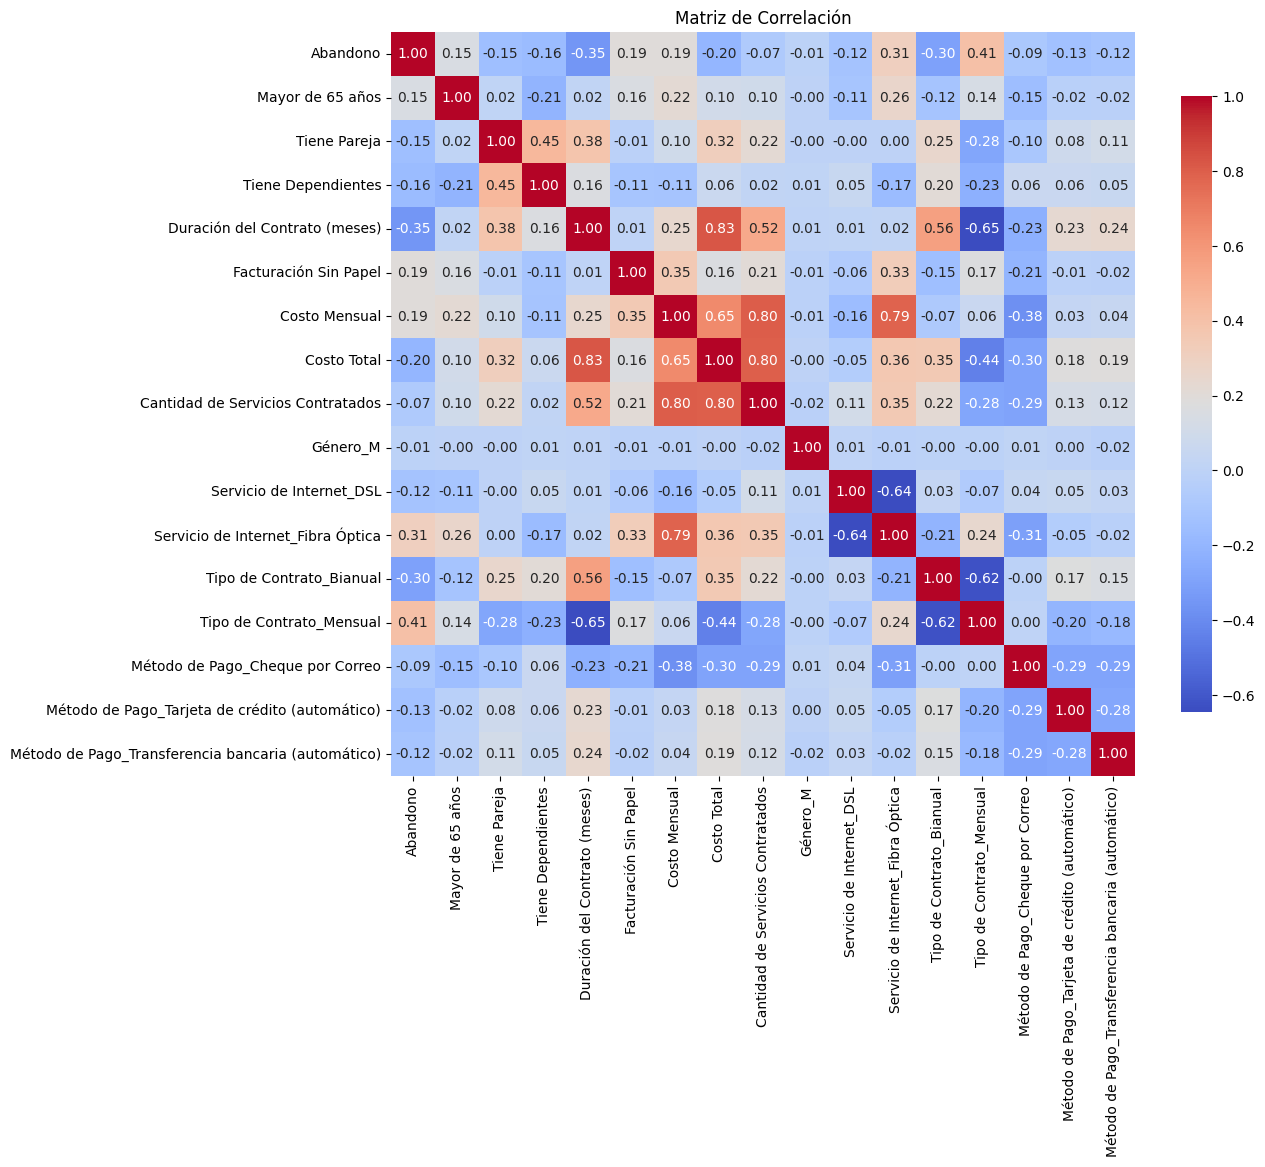

In [122]:
#graficar mapa de calor de la matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación')
plt.show()

Del análisis de correlación puedes concluir lo siguiente:

- **Duración del Contrato** y **Costo Total** presentan una correlación negativa con el abandono, es decir, a menor duración del contrato y menor gasto total, **mayor probabilidad de abandono**.
- Los clientes que permanecen suelen tener contratos más largos y un mayor gasto total.
- Las variables más correlacionadas con el abandono son precisamente la duración del contrato y el gasto total, lo que indica que son factores clave para predecir la cancelación.
- Otras variables pueden tener correlaciones menores, pero estas dos destacan como las más relevantes según la matriz de correlación y los gráficos.

**En resumen:**  
La duración del contrato y el gasto total son variables predictoras importantes del abandono de clientes. Clientes con contratos cortos y bajo gasto tienen mayor riesgo de cancelar el servicio.

## Análisis dirigido

In [ ]:
# Boxplot: Tiempo de contrato vs Abandono
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x=data_encoded['Abandono'], y=data_encoded['Duración del Contrato (meses)'])
plt.title('Distribución del Tiempo de Contrato según Abandono')
plt.xlabel('Abandono')
plt.ylabel('Duración del Contrato')
plt.show()

Los clientes que abandonan suelen tener una menor duración del contrato en comparación con los que permanecen.
Esto se refleja en que la mediana y los cuartiles inferiores del grupo que abandona están más bajos que los del grupo que no abandona.

In [ ]:
# Boxplot: Gasto total vs Abandono
plt.figure(figsize=(8, 5))
sns.boxplot(x=data_encoded['Abandono'], y=data_encoded['Costo Total'])
plt.title('Distribución del Gasto Total según Abandono')
plt.xlabel('Abandono')
plt.ylabel('Gasto Total')
plt.show()


El gasto total de los clientes que abandonan tiende a ser menor que el de los clientes que permanecen.
Esto puede indicar que los clientes que llevan menos tiempo y gastan menos son más propensos a cancelar.

In [ ]:
# Scatter plot: Duración de contrato vs Gasto total, coloreado por Abandono
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data_encoded['Duración del Contrato (meses)'], y=data_encoded['Costo Total'], hue=data_encoded['Abandono'], alpha=0.6)
plt.title('Tiempo de Contrato vs Gasto Total según Abandono')
plt.xlabel('Tiempo de Contrato')
plt.ylabel('Gasto Total')
plt.legend(title='Abandono')
plt.show()

Se observa que la mayoría de los clientes que abandonan se concentran en la zona de baja duración de contrato y bajo gasto total.
Los clientes con mayor duración y mayor gasto tienden a permanecer activos.
Las variables Duración del Contrato y Costo Total están negativamente relacionadas con el abandono:

* A menor duración y menor gasto, mayor probabilidad de abandono.
* A mayor duración y mayor gasto, menor probabilidad de abandono.
* Estos patrones pueden ayudarte a identificar clientes en riesgo de cancelar y a enfocar estrategias de retención.

## Divide el conjunto de datos en entrenamiento y prueba

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#usar la divisio 80-20 para entrenamiento y prueba
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo Random Forest
rdmforest_model = RandomForestClassifier(n_estimators=100, random_state=42)
rdmforest_model.fit(X_train, y_train)

# Hacer predicciones
y_pred = rdmforest_model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Entrenar el modelo XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Evaluar el modelo
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Accuracy XGBoost: {accuracy_xgb}')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Random Forest
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# XGBoost
print("\nXGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Análisis de Desempeño
#### Random Forest
* Accuracy: 0.8006
* Precision: 0.6716
* Recall: 0.4826
* F1-score: 0.5616
* Matriz de Confusión:
* Verdaderos Positivos (TP): 180
* Falsos Positivos (FP): 88
* Verdaderos Negativos (TN): 948
* Falsos Negativos (FN): 193

#### XGBoost
* Accuracy: 0.7878
* Precision: 0.6242
* Recall: 0.4987
* F1-score: 0.5544
* Matriz de Confusión:
* Verdaderos Positivos (TP): 186
* Falsos Positivos (FP): 112
* Verdaderos Negativos (TN): 924
* Falsos Negativos (FN): 187

####Comparación de Desempeño
* Accuracy
  * Random Forest tiene una precisión ligeramente superior (0.8006 vs. 0.7878).
* Precision
  * Random Forest tiene una precisión ligeramente superior (0.6716 vs. 0.6242).
* Recall:
  * XGBoost tiene un recall ligeramente superior (0.4987 vs. 0.4826).
* F1-score:
  * Random Forest tiene un F1-score ligeramente superior (0.5616 vs. 0.5544).

####Matriz de Confusión
* Random Forest tiene más verdaderos negativos (948 vs. 924) y menos falsos positivos (88 vs. 112).
* XGBoost tiene más verdaderos positivos (186 vs. 180) y menos falsos negativos (187 vs. 193).

#### Conclusión sobre el Mejor Desempeño
En términos generales, Random Forest parece tener un mejor desempeño en términos de precisión, F1-score y accuracy. Sin embargo, XGBoost tiene un mejor recall, lo que significa que es mejor para identificar casos positivos (abandono).
####Análisis de Overfitting y Underfitting
* Overfitting
  * Random Forest: No hay indicios claros de overfitting en las métricas proporcionadas. La diferencia entre la precisión en el conjunto de entrenamiento y el conjunto de prueba no es significativa.
  * XGBoost: Similarmente, no hay indicios claros de overfitting. La precisión en el conjunto de prueba es ligeramente menor que en el conjunto de entrenamiento, lo cual es esperado.
* Underfitting
  * Random Forest: El modelo parece estar capturando bien las tendencias de los datos, pero el recall es bajo, lo que sugiere que podría estar subestimando los casos positivos.
  * XGBoost: Similarmente, el modelo parece estar capturando bien las tendencias de los datos, pero el recall es bajo, lo que sugiere que podría estar subestimando los casos positivos.

####Posibles Ajustes
* Random Forest:
  * Aumentar la complejidad: Aumentar el número de árboles (n_estimators) o la profundidad máxima de los árboles (max_depth).
  * Ajustar parámetros: Experimentar con otros parámetros como min_samples_split, min_samples_leaf, y max_features.
* XGBoost:
  * Aumentar la complejidad: Aumentar el número de estimadores (n_estimators) o la profundidad máxima de los árboles (max_depth).
  * Ajustar parámetros: Experimentar con otros parámetros como learning_rate, subsample, y colsample_bytree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Aumentar la complejidad del modelo
rdmforest_model_ajustado = RandomForestClassifier(
    n_estimators=300,        # Más árboles
    max_depth=12,            # Mayor profundidad máxima
    min_samples_split=3,     # Menos muestras para dividir un nodo
    min_samples_leaf=1,      # Menos muestras en una hoja
    max_features='sqrt',     # Número de características a considerar en cada división
    random_state=42
)

rdmforest_model_ajustado.fit(X_train, y_train)
y_pred_2 = rdmforest_model_ajustado.predict(X_test)

# Evaluar el nuevo modelo
from sklearn.metrics import classification_report
print("Reporte clasificación Random Forest ajustado:")
print(classification_report(y_test, y_pred_2))

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Aumentar la complejidad y ajustar parámetros de XGBoost
xgb_model_ajustado = xgb.XGBClassifier(
    n_estimators=300,         # Más árboles
    max_depth=10,             # Mayor profundidad máxima
    learning_rate=0.05,       # Tasa de aprendizaje más baja
    subsample=0.8,            # Porcentaje de muestras para cada árbol
    colsample_bytree=0.8,     # Porcentaje de columnas para cada árbol
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model_ajustado.fit(X_train, y_train)
y_pred_xgb_ajustado = xgb_model_ajustado.predict(X_test)

# Evaluar el modelo ajustado
print("Reporte clasificación XGBoost ajustado:")
print(classification_report(y_test, y_pred_xgb_ajustado))

Comparar nuevamente (verificar y completar)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Random Forest
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2))
print("Recall:", recall_score(y_test, y_pred_2))
print("F1-score:", f1_score(y_test, y_pred_2))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

# XGBoost
print("\nXGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_ajustado))
print("Precision:", precision_score(y_test, y_pred_xgb_ajustado))
print("Recall:", recall_score(y_test, y_pred_xgb_ajustado))
print("F1-score:", f1_score(y_test, y_pred_xgb_ajustado))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_xgb_ajustado))
print(classification_report(y_test, y_pred_xgb_ajustado))